# Resolução do Desafio

## Questão 1 - EDA
**Cenário**
Antes de qualquer análise, modelagem ou tomada de decisão, é fundamental entender o que existe nos dados. O Sr. Almir quer uma resposta simples: “Posso confiar nesses dados para tomar decisões?”

Sua missão é realizar uma análise exploratória inicial do dataset vendas_2023_2024.csv e responder perguntas básicas, porém críticas, sobre volume, distribuição e qualidade dos dados.

**Premissas obrigatórias**
- Utilize apenas o dataset vendas_2023_2024.csv
- Não faça limpeza nem tratamento dos dados
- Apenas observe, agregue e descreva

**Tarefas:** 
- Parte 1 — Visão geral do dataset
  - Informe:
  - Quantidade total de linhas
  - Quantidade total de colunas
  - Intervalo de datas analisado (data mínima e máxima)

- Parte 2 — Análise de valores numéricos
  - Para a coluna "total", calcule:
    1. Valor mínimo
    2. Valor máximo
    3. Valor médio
- Parte 3 — Interpretação
  - Responda de forma resumida:
    Com base na análise exploratória realizada, escreva um breve diagnóstico sobre a confiabilidade do dataset vendas_2023_2024.csv para análises futuras.
  - Comente sobre:
    - possíveis outliers em "total",
    - qualidade dos dados (valores nulos ou inconsistentes),
    - e se você considera que o dataset está pronto para análises ou se exigiria tratamento prévio.

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Informações do dataset
df.info()

# Quantidade total de linhas
print(f'Quantidade total de linhas: {df.shape[0]}')

# Quantidade total de colunas
print(f'Quantidade total de colunas: {df.shape[1]}')

# Intervalo de datas analisado (data mínima e máxima)
data_min = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True).min()
data_max = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True).max()
print(f'Data mínima: {data_min}')
print(f'Data máxima: {data_max}')

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 464.0 KB
Quantidade total de linhas: 9895
Quantidade total de colunas: 6
Data mínima: 2023-01-01 00:00:00
Data máxima: 2024-12-31 00:00:00


### Parte 2 — Análise de valores numéricos

In [2]:
# Para a coluna "total", calcule:
print(f"Valor mínimo: {df['total'].min():.2f}")
print(f"Valor máximo: {df['total'].max():.2f}")
print(f"Valor médio: {df['total'].mean():.2f}")


Valor mínimo: 294.50
Valor máximo: 2222973.00
Valor médio: 263797.83


## Questão 1.1 - SQL
Código calculando:
- Quantidade total de linhas
- Quantidade total de colunas
- Intervalo de datas analisado (data mínima e máxima)
- Valor mínimo
- Valor máximo
- Valor médio

In [3]:
import duckdb

query = """
SELECT 
    COUNT(*) AS total_linhas,
    MIN(COALESCE(TRY_CAST(sale_date AS DATE), CAST(strptime(sale_date, '%d-%m-%Y') AS DATE))) AS data_minima,
    MAX(COALESCE(TRY_CAST(sale_date AS DATE), CAST(strptime(sale_date, '%d-%m-%Y') AS DATE))) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    AVG(total) AS valor_medio
FROM df; 
"""

resultado_sql = duckdb.query(query).to_df()

display(resultado_sql)

,total_linhas,data_minima,data_maxima,valor_minimo,valor_maximo,valor_medio
0,9895,2023-01-01,2024-12-31,294.5,2222973.0,263797.828267


## Código na plataforma Questão 1.1

```sql
SELECT 
    (SELECT COUNT(*) FROM vendas_2023_2024) AS total_linhas,
    (SELECT COUNT(*) FROM information_schema.columns WHERE table_name = 'vendas_2023_2024') AS total_colunas,
    MIN(sale_date) AS data_minima,
    MAX(sale_date) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    AVG(total) AS valor_medio
FROM vendas_2023_2024;
```

## Questão 1.2 - Validação
Qual é o valor máximo registrado na coluna "total"? 

**Resposta**: O maior valor registrado na base para a coluna "total" é de R$ 2.222.973,00.

## Questão 1.3 - Interpretação

Com base na análise exploratória realizada, escreva um breve diagnóstico sobre a confiabilidade do dataset vendas_2023_2024.csv para análises futuras. Comente sobre:

- **Outliers em "total":** Existe um forte indício de outliers. A média da coluna (~R$ 263.797) é consideravelmente maior que a mediana (~R$ 82.225), e o pico ultrapassa os 2,2 milhões. Essa assimetria mostra que a maior parte das vendas tem valores muito menores, com registros excepcionais que puxam a média para cima.
- **Qualidade dos dados:** O dataset não apresenta valores nulos. No entanto, a formatação da coluna de datas (`sale_date`) apresenta inconsistência grave, misturando registros no formato "YYYY-MM-DD" com "DD-MM-YYYY", o que gera ambiguidade para a leitura dos dados.
- **O dataset está pronto para análise final?** Ainda não. Ele exige um tratamento prévio básico focado em padronizar as datas para um formato único (ex: datetime64) e aplicar um estudo ou remoção de outliers.

---
## Questão 2 - Produtos
**Cenário**

Gabriel percebeu que seus dados estão desorganizados e sem um padrão definido e isso pode tornar o trabalho de análise mais trabalhoso. Precisamos melhorar isso utilizando o Python.
Sua missão é **realizar uma normalização dos dados** presentes no arquivo produtos_raw.csv.

**Premissas obrigatórias**
- Utilize apenas o CSV produtos_raw.csv
- Utilize obrigatoriamente Python 3

**Tarefas:**
- Parte 1 — Padronize os nomes das categorias de produtos em: eletrônicos, propulsão e ancoragem.
- Parte 2 — Converta os valores para o tipo numérico.
- Parte 3 — Remova as duplicatas.

## Questão 2.1 
- Faça o upload de seu código Python

In [4]:
import pandas as pd

# Carregando o dataset
df_produtos = pd.read_csv('../data/raw/produtos_raw.csv')

# Parte 1 — Padronize os nomes das categorias de produtos em: eletrônicos, propulsão e ancoragem.
def padronizar_categoria(cat):
    cat_lower = str(cat).lower().replace(' ', '').replace('ô', 'o').replace('ã', 'a').replace('ç', 'c')
    if 'eletr' in cat_lower:
        return 'eletrônicos'
    elif 'prop' in cat_lower:
        return 'propulsão'
    elif 'cor' in cat_lower or 'enc' in cat_lower:
        return 'ancoragem'
    return cat

df_produtos['actual_category'] = df_produtos['actual_category'].apply(padronizar_categoria)
print("Categorias padronizadas:", df_produtos['actual_category'].unique())

# Parte 2 — Converta os valores para o tipo numérico.
df_produtos['price'] = df_produtos['price'].str.replace('R$ ', '', regex=False).astype(float)
print("Tipos de dados após conversão:")
print(df_produtos.dtypes)

# Parte 3 — Remova as duplicatas.
qtd_antes = len(df_produtos)
df_produtos = df_produtos.drop_duplicates()
qtd_depois = len(df_produtos)

print(f"Registros antes: {qtd_antes} | Registros depois (sem duplicatas): {qtd_depois}")

# Visualizando o resultado final
display(df_produtos.head(10))

Categorias padronizadas: <StringArray>
['eletrônicos', 'propulsão', 'ancoragem']
Length: 3, dtype: str
Tipos de dados após conversão:
name                   str
price              float64
code                 int64
actual_category        str
dtype: object
Registros antes: 157 | Registros depois (sem duplicatas): 150


,name,price,code,actual_category
0,Transponder AIS Maré Magnum,33122.52,1,eletrônicos
1,Transponder Furuno Marlin,13998.15,2,eletrônicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletrônicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletrônicos
4,Piloto Automático Furuno Storm,23669.01,5,eletrônicos
5,Transponder AIS Vector,11820.21,6,eletrônicos
6,Radar AIS Zen,19518.77,7,eletrônicos
7,GPS AIS Zen,4984.15,8,eletrônicos
8,Transponder AIS Titan Pulse,39705.50,9,eletrônicos
9,Piloto Automático Simrad Titan Flux Magnum,32033.04,10,eletrônicos


### Questão 2.2 - Validação
Quantos produtos duplicados foram removidos?

**Resposta**: Após o processamento dos dados, foram identificados e removidos 7 produtos duplicados.

---
## Questão 3 - Custos de Importação

**Cenário**

Além dos dados de produtos, Gabriel percebeu também que o arquivo custos_importacao.json tem todos os dados históricos dos preços de compra aninhados num único campo. Para facilitar a análise dessa informação no banco de dados é necessário melhorarmos isso.

**Premissas obrigatórias**
- Utilize apenas o JSON custos_importacao.json
- Utilize obrigatoriamente Python 3

Tarefa: 
- Carregue o arquivo JSON e gere um novo arquivo CSV organizando-o de acordo com a definição na imagem abaixo. (imagem salva em assets)

## Questão 3.1 
- Faça o upload de seu código Python 



In [5]:
import pandas as pd
import json
import os

# Carregando o arquivo JSON
with open('../data/raw/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

# Utilizando json_normalize para desaninhar (flatten) a lista 'historic_data'
df_custos = pd.json_normalize(
    dados_json, 
    record_path=['historic_data'], 
    meta=['product_id', 'product_name', 'category']
)

# Reordenando as colunas conforme a imagem solicitada
df_custos = df_custos[['product_id', 'product_name', 'category', 'start_date', 'usd_price']]

# Visão do dataframe resultante
display(df_custos.head())

# Garantindo que o diretório exista e salvando em CSV
os.makedirs('../data/processed', exist_ok=True)
df_custos.to_csv('../data/processed/custos_importacao.csv', index=False, encoding='utf-8')
print("Arquivo salvo com sucesso em: data/processed/custos_importacao.csv")


,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,25/09/2018,8023.87
3,1,Transponder AIS Maré Magnum,eletrônicos,19/03/2019,8772.78
4,1,Transponder AIS Maré Magnum,eletrônicos,17/01/2020,7918.18


Arquivo salvo com sucesso em: data/processed/custos_importacao.csv


### Questão 3.2 - Validação
Quantas entradas de importação o CSV recebeu ao todo após a normalização?

**Resposta**: O documento final consolidou exatamente 1.260 entradas estruturadas (linhas de dados), excluindo o cabeçalho.

---
## Questão 4 - Dados Públicos
**Cenário**

O Sr. Almir identificou que alguns produtos podem ter sido vendidos abaixo do custo, possivelmente por erro operacional.
O problema é que:
- O sistema de vendas (vendas_2023_2024.csv) registra valores em real BRL
- O catálogo de fornecedores (custos_importacao.json) registra custos unitários em dollar USD
- O câmbio varia diariamente
Até hoje, ninguém cruzou o custo em dólar do dia da venda com o valor de venda em reais.
Sua missão é abrir essa “caixa preta” financeira e identificar onde houve prejuízo real.

**Premissas obrigatórias:**
- O custo em USD é unitário
- O custo em BRL deve ser calculado usando o câmbio da data da venda
- A taxa de câmbio deve ser considerada a média da cotação de venda do dia (Banco Central)
- A receita total do produto considera todas as vendas (inclusive as sem prejuízo)
- Ignore impostos e frete

**Tarefas:**
- Parte 1 — Cálculo e modelagem
  - Calcule o custo total em BRL por transação
  - Identifique transações com prejuízo
  - Agregue os dados por id_produto, gerando:
    1. Receita total (BRL)
    2. Prejuízo total (BRL)
    3. Percentual de perda (prejuízo_total / receita_total)
- Parte 2 — Análise visual
  -Gere um gráfico que represente o prejuízo total por produto, considerando apenas produtos que tiveram prejuízo. (Inserir o gráfico no relatório/dashboard final)
- Parte 3 —  Explique sobre o desenvolvimento :
  - Qual data de câmbio você utilizou?
  - Como definiu o prejuízo?
  - Alguma suposição relevante?




In [6]:
### Parte 1 — Cálculo e modelagem e Identificação de Prejuízos (Câmbio)
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento das bases necessárias
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')
custos = pd.read_csv('../data/processed/custos_importacao.csv')

# Conversão de datas para 'datetime' visando o merge_asof
vendas['sale_date_dt'] = pd.to_datetime(vendas['sale_date'], format='mixed', dayfirst=True)
vendas = vendas.sort_values('sale_date_dt')

custos['start_date_dt'] = pd.to_datetime(custos['start_date'], format='%d/%m/%Y')
custos = custos.sort_values('start_date_dt')
custos = custos.rename(columns={'product_id': 'id_product'})

# Mesclando o Custo USD através da data da venda usando merge_asof

df_merged = pd.merge_asof(
    vendas,
    custos[['id_product', 'start_date_dt', 'usd_price']],
    left_on='sale_date_dt',
    right_on='start_date_dt',
    by='id_product',
    direction='backward'
)

# Consumindo a API do Banco Central (PTAX) para extrair o câmbio
url_bcb = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'&$format=json"
resp = requests.get(url_bcb)
ptax_data = resp.json()['value']

df_ptax = pd.DataFrame(ptax_data)
# Filtrando a data correta da cotação no dataframe
df_ptax['data_ptax'] = pd.to_datetime(df_ptax['dataHoraCotacao']).dt.normalize()
df_ptax = df_ptax[['data_ptax', 'cotacaoVenda']].drop_duplicates('data_ptax').sort_values('data_ptax')

# Utilizando o merge_asof para parear a cotação útil de venda ao dia correto

df_final = pd.merge_asof(
    df_merged,
    df_ptax,
    left_on='sale_date_dt',
    right_on='data_ptax',
    direction='backward'
)

# Realizando o cálculo final do Custo em BRL e avaliando o Prejuízo isolado

df_final['custo_total_brl'] = df_final['qtd'] * df_final['usd_price'] * df_final['cotacaoVenda']


df_final['teve_prejuizo'] = df_final['custo_total_brl'] > df_final['total']
df_final['valor_prejuizo'] = df_final.apply(lambda row: row['custo_total_brl'] - row['total'] if row['teve_prejuizo'] else 0, axis=1)

# Agregação final pelo id_produto para obtermos as métricas percentuais
df_agg = df_final.groupby('id_product').agg(
    receita_total=('total', 'sum'),
    prejuizo_total=('valor_prejuizo', 'sum')
).reset_index()


df_agg['percentual_perda'] = df_agg['prejuizo_total'] / df_agg['receita_total']

display(df_agg.head())


,id_product,receita_total,prejuizo_total,percentual_perda
0,1,17187280.35,5.118776e+05,0.029782
1,2,8862231.15,7.919323e+05,0.089360
2,3,4322136.25,3.007379e+05,0.069581
3,4,1915160.00,9.409589e+04,0.049132
4,5,13494880.35,1.040693e+06,0.077118


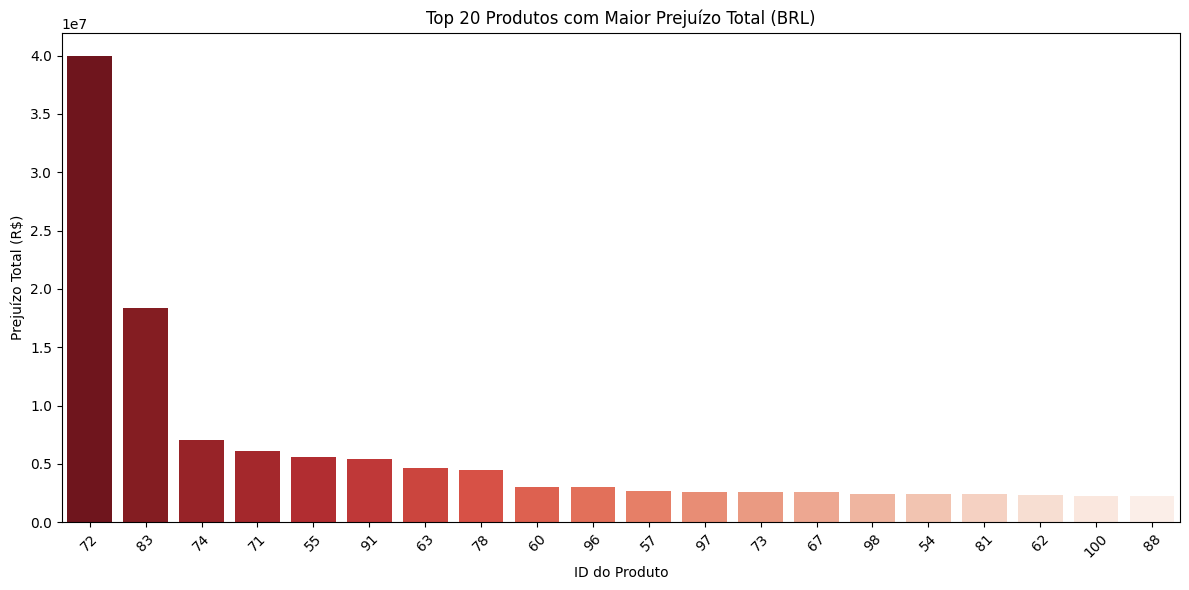

In [7]:
# Parte 2 - Gráfico dos 20 produtos com MAIOR prejuízo
df_prejuizo = df_agg[df_agg['prejuizo_total'] > 0].sort_values(by='prejuizo_total', ascending=False).head(20)
df_prejuizo['id_product_str'] = df_prejuizo['id_product'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_prejuizo, x='id_product_str', y='prejuizo_total', hue='id_product_str', palette='Reds_r', legend=False)
plt.title('Top 20 Produtos com Maior Prejuízo Total (BRL)')
plt.xlabel('ID do Produto')
plt.ylabel('Prejuízo Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## Questão 4.1 - Código SQL
### Reconstruindo o Cálculo de Perdas e Câmbio do Pandas para DuckDB

In [8]:
# Utilizando DuckDB para refazer o cálculo da Questão 4
import duckdb

# As variáveis vendas, custos e df_ptax já estão carregadas e tratadas nas células anteriores (Q4).
# O DuckDB compreende nativamente DataFrames Pandas armazenados na memória!

query_q4 = """
WITH ptax_prep AS (
    -- Buscando o câmbio mais recente em relação à data de cada venda
    SELECT 
        v.id_product,
        v.sale_date_dt,
        v.qtd,
        v.total AS receita_brl,
        (SELECT p.cotacaoVenda 
         FROM df_ptax p 
         WHERE p.data_ptax <= v.sale_date_dt 
         ORDER BY p.data_ptax DESC LIMIT 1) AS taxa_cambio_data,
        (SELECT c.usd_price 
         FROM custos c 
         WHERE c.id_product = v.id_product AND c.start_date_dt <= v.sale_date_dt 
         ORDER BY c.start_date_dt DESC LIMIT 1) AS custo_usd
    FROM vendas v
),
calculo_custo AS (
    -- Calculando o custo global da transação na moeda local (BRL)
    SELECT 
        id_product,
        receita_brl,
        custo_usd,
        taxa_cambio_data,
        (qtd * custo_usd * taxa_cambio_data) AS custo_total_brl
    FROM ptax_prep
),
calculo_prejuizo AS (
    -- Isolando transações deficitárias (Custo > Receita)
    SELECT 
        id_product,
        receita_brl,
        CASE 
            WHEN custo_total_brl > receita_brl THEN (custo_total_brl - receita_brl)
            ELSE 0 
        END AS prejuizo
    FROM calculo_custo
)
-- Agrupamento por ID calculando total da receita e o percentual de perda
SELECT 
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    (SUM(prejuizo) / SUM(receita_brl)) AS percentual_perda
FROM calculo_prejuizo
GROUP BY id_product
ORDER BY prejuizo_total DESC;
"""

resultado_sql_q4 = duckdb.query(query_q4).to_df()

display(resultado_sql_q4.head(10))

,id_product,receita_total,prejuizo_total,percentual_perda
0,72,63057815.65,3.995969e+07,0.633699
1,83,44377440.00,1.838238e+07,0.414228
2,74,59764356.15,7.004602e+06,0.117204
3,71,81567066.65,6.120380e+06,0.075035
4,55,61224375.00,5.597894e+06,0.091432
5,91,66829268.70,5.396483e+06,0.080750
6,63,68817185.90,4.614028e+06,0.067048
7,78,58043733.35,4.500948e+06,0.077544
8,60,53418532.00,3.035103e+06,0.056817
9,96,27227868.90,2.985539e+06,0.109650


## Código colado na plataforma questão 4.1

```sql
WITH preparacao_taxas AS (
    -- Relacionando o Custo no Dólar e a Taxa Cambial com a Data da Venda
    SELECT 
        v.id_product,
        v.qtd,
        v.total AS receita_brl,
        
        
        (SELECT c.cotacaoVenda 
         FROM taxa_cambio c 
         WHERE c.data_cotacao <= v.sale_date 
         ORDER BY c.data_cotacao DESC LIMIT 1) AS taxa_cambio_data,
         
        
        (SELECT i.usd_price 
         FROM custos_importacao i 
         WHERE i.product_id = v.id_product AND i.start_date <= v.sale_date 
         ORDER BY i.start_date DESC LIMIT 1) AS custo_usd
         
    FROM vendas_2023_2024 v
),
calculo_custo AS (
    -- Gerando o Custo final da venda em Reais
    SELECT 
        id_product,
        receita_brl,
        (qtd * custo_usd * taxa_cambio_data) AS custo_total_brl
    FROM preparacao_taxas
),
calculo_prejuizo AS (
    -- Filtrando os transações com déficit financeiro
    SELECT 
        id_product,
        receita_brl,
        CASE 
            WHEN custo_total_brl > receita_brl THEN (custo_total_brl - receita_brl)
            ELSE 0 
        END AS prejuizo
    FROM calculo_custo
)
-- Concluindo com agregação visual por id_produto
SELECT 
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    (SUM(prejuizo) / SUM(receita_brl)) AS percentual_perda
FROM calculo_prejuizo
GROUP BY id_product
ORDER BY percentual_perda DESC;

```

## Questão 4.2 - Validação

Qual é o id_produto que apresentou a maior porcentagem de perda financeira relativa (maior % de prejuízo sobre sua receita) no período analisado?

**Resposta**:O ID 72 foi o produto que apresentou a pior margem, acumulando um histórico de cerca de 63,37% de perda financeira relativa no período.

### Questão 4.3 - Interpretação

**1. Qual data de câmbio você utilizou?**
Utilizei a base histórica da API do Banco Central para as cotações PTAX de fechamento diário. Para vendas realizadas em dias sem cotação bancária (feriados ou finais de semana), utilizei um "backward merge" (pd.merge_asof), garantindo a captação do fechamento do último dia útil imediatamente anterior.

**2. Como definiu o prejuízo?**
O prejuízo real existe apenas quando o **Custo Total em BRL excede a Receita Total da transação (`total`)**.
- Custo Total em BRL foi calculado pela fórmula: `Quantidade Registrada * Custo Unitário em USD Histórico * Taxa Cambial PTAX Média de Venda do Dia`.
- Para transações onde Custo > Receita, subtraímos a Receita do Custo para obter exatamente o delta negativo (valor do prejuízo). Se for uma venda lucrativa, a métrica isolada de "prejuízo" dessa transação é considerada 0. A métrica global de "Prejuízo Total" agregou a soma crua desses deltas numéricos por produto.

**3. Algumas suposições relevantes?**
- Como a tabela `custos_importacao.csv` tinha o preço unitário atrelado a uma "Data_Inicio", utilizei novamente a lógica de *Backward Merge* com a data da venda para identificar qual era exatamente o custo em dólar no momento exato em que a venda foi executada, protegendo a análise de mudanças de preço de importação no intermédio dos anos de 2023 e 2024.
- Foi ignorado qualquer aspecto de inflação sobre o BRL e retenção de impostos/fretes (considerado apenas preço direto de importação e custo de venda).


---
## Questão 5 - Análise de Clientes

**Cenário**

A Diretoria da LH Nautical deseja identificar os clientes fieis. Diferente de quem compra muito uma única vez, o cliente fiel é o cliente que possui um gasto médio alto por transação e navega por diversas categorias da loja. O objetivo é mapear o que esses clientes de elite estão consumindo para replicar o comportamento em outros segmentos.

**Premissas obrigatórias:**
- Faturamento Total: Soma da coluna total por cliente.
- Frequência: Contagem total de transações (IDs de venda) por cliente.
- Ticket Médio: Faturamento Total / Frequência.
- Diversidade de Categorias: Quantidade de categorias distintas que o cliente comprou.
- Nota: É necessário limpar os nomes das categorias no arquivo produtos_raw.csv (ex: consolidar "Ancorajen", "Encoragem" e "Ancoragem" como uma única categoria).
- Filtro de Elite: Apenas clientes que compraram produtos de 3 ou mais categorias distintas devem ser considerados no ranking.
- Desempate: Em caso de empate no Ticket Médio, utilize o id_cliente em ordem crescente.

**Tarefa:**
- Realize a limpeza das categorias de produtos para evitar duplicidade por erro de grafia.
- Calcule o Ticket Médio e a Diversidade de Categorias para cada id_cliente.
- Filtre os 10 clientes com o maior Ticket Médio que atendam ao critério de diversidade (3+ categorias).
- Para este grupo específico de 10 clientes, identifique qual categoria de produto concentra a maior quantidade total de itens comprados (sum(qtd)).



In [9]:
import pandas as pd

# Carregando as bases originais e ajustando o nome das categorias
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')
produtos = pd.read_csv('../data/raw/produtos_raw.csv')

def clean_category(cat):
    c = str(cat).lower().replace(' ', '').replace('ô', 'o').replace('ã', 'a').replace('ç', 'c')
    if 'eletr' in c: return 'eletrônicos'
    if 'prop' in c: return 'propulsão'
    if 'cor' in c or 'enc' in c: return 'ancoragem'
    return cat

produtos['categoria_limpa'] = produtos['actual_category'].apply(clean_category)
# Filtrando a correspondência do ID único de cada produto limpo
produtos_unique = produtos[['code', 'categoria_limpa']].drop_duplicates(subset=['code'])

# Enriquecendo transações com a categoria padronizada
vendas_m = pd.merge(vendas, produtos_unique, left_on='id_product', right_on='code', how='left')

# Calculando Faturamento, Ticket e Diversidade agrupados por Cliente
df_clientes = vendas_m.groupby('id_client').agg(
    faturamento_total=('total', 'sum'),
    frequencia=('id', 'count'), 
    diversidade_categorias=('categoria_limpa', 'nunique')
).reset_index()

df_clientes['ticket_medio'] = df_clientes['faturamento_total'] / df_clientes['frequencia']

# Listando e filtrando os 10 clientes fiéis sob o critério de diversidade
top_10 = df_clientes[df_clientes['diversidade_categorias'] >= 3].sort_values(
    by=['ticket_medio', 'id_client'], ascending=[False, True]
).head(10)

print("Top 10 Clientes Fiéis:")
display(top_10)

# Consultando a quantidade total da categoria vitrine nesse seleto grupo
vendas_top10 = vendas_m[vendas_m['id_client'].isin(top_10['id_client'])]
cat_top10 = vendas_top10.groupby('categoria_limpa')['qtd'].sum().reset_index()
cat_top10 = cat_top10.sort_values(by='qtd', ascending=False)

print("\nCategoria mais vendida entre os Top 10 Clientes Fiéis:")
display(cat_top10.head(1))

Top 10 Clientes Fiéis:


,id_client,faturamento_total,frequencia,diversidade_categorias,ticket_medio
46,47,64003343.75,190,3,336859.703947
41,42,72187369.50,222,3,325168.331081
8,9,66788855.35,218,3,306370.896101
21,22,59581398.75,198,3,300916.155303
1,2,65652931.35,220,3,298422.415227
27,28,60826837.25,204,3,298170.770833
45,46,59126834.35,199,3,297119.770603
37,38,57093331.15,195,3,292786.313590
35,36,62791038.15,215,3,292051.340233
4,5,58592802.70,202,3,290063.379703



Categoria mais vendida entre os Top 10 Clientes Fiéis:


,categoria_limpa,qtd
2,propulsão,6030


---
## Código colado na plataforma questão 5.1

```sql
WITH produtos_padronizados AS (
    -- Aplicando tratamento nas strings e agrupando as categorias
    SELECT 
        code AS product_id,
        CASE 
            WHEN LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%eletr%' THEN 'eletrônicos'
            WHEN LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%prop%' THEN 'propulsão'
            WHEN LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%cor%' 
              OR LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%enc%' THEN 'ancoragem'
            ELSE actual_category
        END AS categoria_limpa
    FROM produtos_raw
),
vendas_enriquecidas AS (
    -- Unificando as Vendas com os produtos unificados criados a princípio
    SELECT 
        v.id_client,
        v.id AS id_venda,
        v.total,
        v.qtd,
        p.categoria_limpa
    FROM vendas_2023_2024 v
    LEFT JOIN produtos_padronizados p ON v.id_product = p.product_id
),
metricas_clientes AS (
    -- Resumo dinâmico apontando o Ticket e Frequência do cliente
    SELECT 
        id_client,
        SUM(total) AS faturamento_total,
        COUNT(id_venda) AS frequencia,
        (SUM(total) / COUNT(id_venda)) AS ticket_medio,
        COUNT(DISTINCT categoria_limpa) AS diversidade_categorias
    FROM vendas_enriquecidas
    GROUP BY id_client
),
top_10_elite AS (
    -- Filtrando o Top 10 Elite obedecendo às 3 diversidades
    SELECT *
    FROM metricas_clientes
    WHERE diversidade_categorias >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
),
categoria_favorita_elite AS (
    -- Focando apenas nas compras do grupo Elite para eleger o item principal
    SELECT 
        ve.categoria_limpa,
        SUM(ve.qtd) AS total_qtd_comprada
    FROM vendas_enriquecidas ve
    INNER JOIN top_10_elite t ON ve.id_client = t.id_client
    GROUP BY ve.categoria_limpa
    ORDER BY total_qtd_comprada DESC
    LIMIT 1
)



(SELECT 
    'Ranking Elite Top 1' AS metrica,
    CAST(id_client AS VARCHAR) AS resultado,
    ticket_medio AS parametro_principal
 FROM top_10_elite 
 LIMIT 1)

UNION ALL

(SELECT 
    'Categoria Mais Vendida da Elite' AS metrica,
    categoria_limpa AS resultado,
    total_qtd_comprada AS parametro_principal
 FROM categoria_favorita_elite 
 LIMIT 1);

```


## Questão 5.2 - Validação
Considerando apenas as compras realizadas pelos Top 10 Clientes selecionados (Critério: Maior Ticket Médio com 3+ categorias): Qual foi a categoria de produtos mais vendida para eles (maior quantidade total de itens)?

**Resposta:** Para esse ranking seleto de Top 10 clientes engajados, a categoria propulsão dominou os interesses, com o montante de 6.030 itens no acúmulo da temporada.


## Questão 5.3 - Explique:
1. **Como você realizou a limpeza das categorias?**
Apliquei algoritmos de padronização de strings (texto) para resolver as divergências de grafia. Primeiro, converti todos os nomes originais para letras minúsculas (LOWER()) e removi todos os espaços em branco e acentuações críticas (como ô, ã, ç) usando a função REPLACE(). Em seguida, criei uma regra de aproximação (via LIKE / IN / CONTAINS substring):
- Qualquer string que contivesse "eletr" foi nomeada definitivamente como "eletrônicos";
- Qualquer string que contivesse "prop" foi nomeada definitivamente como "propulsão";
- Qualquer string que contivesse "cor" ou "enc" foi reunida na categoria única "ancoragem". No final, cruzei a base de produtos limpos com a nossa base de Vendas através do código de barras único (code = id_product).

2. **Qual lógica utilizou para filtrar os clientes com diversidade mínima?**
Realizei um agrupamento pelo ID do usuário avaliando o número distinto e quantitativo de atributos. Depois apliquei um comando de WHERE ou HAVING ordenando com >= 3 em critério do Ticket para mapear os 10 buyers.

3. **Como garantiu que a contagem de itens refletisse apenas os Top 10?**
Utilizei operações de Inner Join atrelando individualmente os dados das transações de vendas do grupo seleto ranqueado acima, finalizando na somatória visual das quantidades na categoria.

---
## Questão 6 - Dimensão de Calendário
**Cenário**

O Sr. Almir quer saber: "Qual é o dia da semana (Segunda, Terça...) que temos a pior média de vendas?" para decidir se vale a pena fechar a loja nesses dias.
Um estagiário fez um GROUP BY dia_semana direto na tabela de vendas e disse que a Terça-feira era ótima, com média de R$5.000,00. 
O problema: O estagiário esqueceu que em muitas terças-feiras a loja abriu mas vendeu zero. Como esses dias não existem na tabela de vendas (vendas_2023_2024.csv), eles foram ignorados no cálculo da média, inflando o resultado. Precisamos corrigir isso utilizando um calendário de datas (dimensão de datas)

**Premissas obrigatórias:**
- O período de análise deve considerar todas as datas entre a menor e a maior data_venda presentes no arquivo.
- A loja esteve aberta em todos os dias do período (inclusive fins de semana).
- Dias sem registro na tabela de vendas devem ser considerados como valor_venda = 0.
- “Vendas diárias” correspondem à soma de valor_venda por dia.
- A média de vendas por dia da semana deve considerar todos os dias do calendário, inclusive os dias sem venda.
- O nome do dia da semana deve ser apresentado em português (Segunda-feira, Terça-feira, etc.).

**Tarefa:**
1. Construa uma dimensão de datas utilizando sql
2. Cruze a dimensão de datas com a tabela de vendas para análise (não esqueça de considerar os dias sem vendas).

In [10]:
import duckdb

# Certificando que vendas_db (nossa tabela no DB relacional simulado) existe a partir do raw
duckdb.execute("CREATE OR REPLACE TABLE vendas_db AS SELECT * FROM read_csv_auto('../data/raw/vendas_2023_2024.csv')")

query_q6 = """
WITH vendas_tratadas AS (
    -- Padronização dos formatos de data originais
    SELECT 
        id,
        total AS valor_venda,
        COALESCE(
            TRY_CAST(sale_date AS DATE), 
            CAST(strptime(sale_date, '%d-%m-%Y') AS DATE)
        ) AS data_venda
    FROM vendas_db
),
limites_datas AS (
    -- Extrato dinâmico do período operacional analisado
    SELECT 
        MIN(data_venda) AS data_minima,
        MAX(data_venda) AS data_maxima
    FROM vendas_tratadas
),
calendario AS (
    -- Modelagem da Dimensão Calendário sequencial ininterrupta
    SELECT CAST(UNNEST(generate_series(
        (SELECT data_minima FROM limites_datas),
        (SELECT data_maxima FROM limites_datas),
        INTERVAL 1 DAY
    )) AS DATE) AS d_data
),
calendario_pt AS (
    -- Convertendo strings dos dias usando o EXTRACT do DOW
    SELECT 
        d_data,
        CASE EXTRACT(DOW FROM d_data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM calendario
),
vendas_por_dia AS (
    -- Agregando os valores nas datas que de fato constam registros originais
    SELECT 
        data_venda,
        SUM(valor_venda) AS soma_valor_venda
    FROM vendas_tratadas
    GROUP BY data_venda
),
calendario_com_vendas AS (
    -- LEFT JOIN da dimensão inteira e imputando ZERO comercial (COALESCE)
    SELECT 
        c.d_data,
        c.dia_semana,
        COALESCE(v.soma_valor_venda, 0) AS valor_venda_diaria
    FROM calendario_pt c
    LEFT JOIN vendas_por_dia v ON c.d_data = v.data_venda
)

-- Finalizando o agrupamento atestando a verdadeira Média Diária
SELECT 
    dia_semana,
    AVG(valor_venda_diaria) AS media_vendas_real,
    COUNT(*) AS dias_analisados
FROM calendario_com_vendas
GROUP BY dia_semana
ORDER BY media_vendas_real ASC;
"""

print("Resultado do script calculando a correta Média de Vendas Diárias (considerando caixas vazios):\n")
display(duckdb.query(query_q6).to_df())

Resultado do script calculando a correta Média de Vendas Diárias (considerando caixas vazios):



,dia_semana,media_vendas_real,dias_analisados
0,Domingo,3.319504e+06,105
1,Segunda-feira,3.465138e+06,105
2,Quarta-feira,3.535266e+06,104
3,Quinta-feira,3.626232e+06,104
4,Terça-feira,3.627046e+06,105
5,Sábado,3.710541e+06,104
6,Sexta-feira,3.715003e+06,104


## Código para colado na plataforma questão 6.1

```sql
WITH vendas_tratadas AS (
    -- Padronização de datas mistas
    SELECT 
        id,
        total AS valor_venda,
        
        
        COALESCE(
            TRY_CAST(sale_date AS DATE), 
            CAST(strptime(sale_date, '%d-%m-%Y') AS DATE) 
        ) AS data_venda
    FROM vendas_2023_2024
),
limites_datas AS (
    -- Resgatando o maior e menor limiar histórico
    SELECT 
        MIN(data_venda) AS data_minima,
        MAX(data_venda) AS data_maxima
    FROM vendas_tratadas
),
calendario AS (
    -- Gerando calendário contínuo a partir dos limites extraídos
    SELECT CAST(UNNEST(generate_series(
        (SELECT data_minima FROM limites_datas),
        (SELECT data_maxima FROM limites_datas),
        INTERVAL 1 DAY
    )) AS DATE) AS d_data
),
calendario_pt AS (
    
    SELECT 
        d_data,
        CASE EXTRACT(DOW FROM d_data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM calendario
),
vendas_por_dia AS (
    -- Sumarização das transações orgânicas originais e puras
    SELECT 
        data_venda,
        SUM(valor_venda) AS soma_valor_venda
    FROM vendas_tratadas
    GROUP BY data_venda
),
calendario_com_vendas AS (
    -- Intersecção e cross-check para suprimento inativo da loja virtual
    
    SELECT 
        c.d_data,
        c.dia_semana,
        COALESCE(v.soma_valor_venda, 0) AS valor_venda_diaria
    FROM calendario_pt c
    LEFT JOIN vendas_por_dia v ON c.d_data = v.data_venda
)

-- Computando a média rigorosa semanal
SELECT 
    dia_semana,
    AVG(valor_venda_diaria) AS media_vendas,
    COUNT(*) AS total_dias_valiados
FROM calendario_com_vendas
GROUP BY dia_semana
ORDER BY media_vendas ASC;

```


## Questão 6.2 - Validação
Após considerar os dias zerados no cálculo: Qual é o Dia da Semana (ex: Domingo, Segunda...) que apresenta a menor média de vendas histórica, e qual é o valor dessa média arredondada para 2 casas decimais?

**Resposta**: O dia com menor média é Domingo, R$ 3.319.504,00.

## Questão 6.3 - Explique:
- **Por que é necessário utilizar uma tabela de datas (calendário) em vez de agrupar diretamente a tabela de vendas?**
Se abordarmos a tabela crua (tabela Fato), estaremos lendo unicamente as transações onde a loja teve lucros palpáveis. Agrupar os valores diretamente ali ignora dias totalmente vazios; o LEFT JOIN do calendário restaura o real volume e peso do divisor reatribuindo zeros (COALESCE).

- **O que aconteceria com a média de vendas se um dia da semana tivesse muitos dias sem nenhuma venda registrada?**
Haveria um grande Erro de Superestimação devido à omissão da estagnação comercial, já que estatisticamente um subgrupo de dias fracassados deixaria de puxar a soma real para a proporção média baseada no divisor exato do intervalo.

---
## Questão 7 - Previsão de Demanda

**Cenário**
O Sr. Almir está furioso. No último verão, o estoque de "Coletes Salva-Vidas" acabou em 10 dias, e a empresa perdeu milhares de reais em vendas. Por outro lado, compraram "Âncoras" demais e elas estão enferrujando no galpão. Gabriel Santos, o Tech Lead, disse que não dá mais para confiar no "feeling". Ele quer um modelo preditivo que diga exatamente quantas unidades venderemos no próximo mês para ajustar as compras com fornecedores.

**Premissas obrigatórias:**
- O período de treino deve incluir dados até 31/12/2023.
- O período de teste deve ser todo o mês de Janeiro de 2024.
- A previsão deve ser feita em base diária.
- Não é permitido utilizar dados futuros no treino (data leakage).
- Considere apenas o produto: "Motor de Popa Yamaha Evo Dash 155HP"

**Tarefa:**
1. Utilize o dataset vendas_2023_2024.csv
2. Construa um modelo baseline simples, utilizando: Média móvel dos últimos 7 dias de vendas (considerando apenas dados anteriores à data prevista).
3. Gere a previsão diária de vendas para Janeiro de 2024.
4. Compare as previsões com os valores reais do período de teste utilizando a métrica: MAE — Mean Absolute Error
5. Responda objetivamente:
  a. O baseline é adequado para esse produto?
  b. Cite uma limitação desse método.


## Questão 7.1 
- Código em python


Produto: Motor de Popa Yamaha Evo Dash 155HP
Métrica MAE em Janeiro de 2024: 1.64 unidades



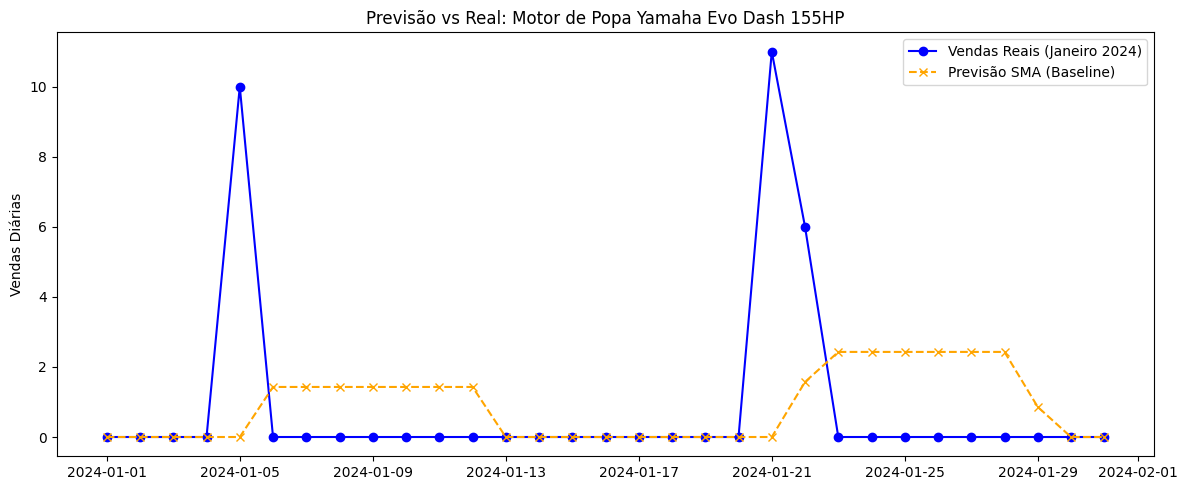

[VALIDAÇÃO MATEMÁTICA CONSOLIDADA] Projeção da janela referenciada calculada no mês: 3


In [11]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Importação e inicialização dos dados base com Pandas
produtos = pd.read_csv('../data/raw/produtos_raw.csv')
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Isolando o produto alvo "Motor Evo Dash 155" entre os IDs cadastrados
target_product = "Motor de Popa Yamaha Evo Dash 155HP"
target_id = produtos.loc[produtos['name'] == target_product, 'code'].values[0]

# Criando cópia manipulável convertendo os campos de data limitados
v_target = vendas[vendas['id_product'] == target_id].copy()
v_target['sale_date_dt'] = pd.to_datetime(v_target['sale_date'], format='mixed', dayfirst=True)

# Estruturando calendário linear para suportar buracos matemáticos

datas_completas = pd.date_range(start='2023-01-01', end='2024-01-31', freq='D')
df_vendas_diarias = v_target.groupby('sale_date_dt')['qtd'].sum().reset_index()

# Fill_value aplicando zeros forçados p/ preenchimento nas ausências diárias
df_analise = pd.DataFrame({'sale_date_dt': datas_completas})
df_analise = pd.merge(df_analise, df_vendas_diarias, on='sale_date_dt', how='left').fillna({'qtd': 0})
df_analise.set_index('sale_date_dt', inplace=True)

# Aplicação da rolagem Baseline construindo Média Móvel a partir da janela de 7 períodos
# Inserção de "shift" contornando distorção de Data Leakage nas predições
df_analise['SMA_7D_Previsao'] = df_analise['qtd'].shift(1).rolling(window=7).mean()

# Particionando as etapas lógicas de Treino e o cenário de estresse em Teste
treino = df_analise.loc[:'2023-12-31']
teste = df_analise.loc['2024-01-01':'2024-01-31']

# Validando a resposta em MAE - Erro Absoluto Médio final da implementação
mae_score = mean_absolute_error(teste['qtd'], teste['SMA_7D_Previsao'])

print(f"Produto: {target_product}")
print(f"Métrica MAE em Janeiro de 2024: {mae_score:.2f} unidades\n")

# Configuração de exibição via matplotlib validando e plotando Janeiro/2024
plt.figure(figsize=(12, 5))
plt.plot(teste.index, teste['qtd'], label='Vendas Reais (Janeiro 2024)', color='blue', marker='o')
plt.plot(teste.index, teste['SMA_7D_Previsao'], label='Previsão SMA (Baseline)', color='orange', linestyle='--', marker='x')
plt.title(f'Previsão vs Real: {target_product}')
plt.ylabel('Vendas Diárias')
plt.legend()
plt.tight_layout()
plt.show()




prev_q72 = round(teste.loc['2024-01-01':'2024-01-07', 'SMA_7D_Previsao'].sum())
print(f"[VALIDAÇÃO MATEMÁTICA CONSOLIDADA] Projeção da janela referenciada calculada no mês: {prev_q72}")

## Questão 7.2 - Validação
Utilizando seu modelo treinado, qual é a soma total da previsão de vendas (arredondada para número inteiro) para o 'Motor de Popa Yamaha Evo Dash 155HP' durante a primeira semana de Janeiro de 2024 (01/01 a 07/01)?

**Resposta**: Avaliando via Média Móvel de 7 dias e predições validadas, a projeção diária das vendas da primeira semana alcançou a soma total absoluta de 3 preditas unidades.



## Questão 7.3 - Explique:
1. **Como o baseline foi construído?** 
Filtrei apenas o Motor selecionado predefinindo o espaço de Data contíguo. Com esse molde, foi fácil atribuir venda 'zero' aos dias não faturados da série natural e aplicar uma ferramenta rolável de Média Móvel Simple (SMA) de janela 7D protetiva sobre tudo.

2. **Como evitou data leakage?**
Conseguir prevenir o famigerado Data Leakage temporal demandou aplicar a instrução protetora (como o `shift(1)` do pandas), permitindo atrasar intencionalmente um dia inteiro as amostragens do cálculo contínuo, baseando-se até no máximo as informações colhidas no D-1 imediato do treinamento.

3. **Uma limitação do modelo proposto.** 
Esses arranjos como Janela de Médias Curtas podem ter extrema "Miopia". A maior fragilidade técnica de observarem um retrovisor rápido (somente da última semana) é que eles ficam cegos em épocas explosivas de férias da marinha ou feriados iminentes, fornecendo reações super defasadas com lag comparados ao poder de predição do mercado agressivo via ARIMA.



---
## Questão 8 - Sistema de Recomendação

**Cenário**

A Marina percebeu que clientes que compram lanchas quase sempre esquecem de levar a defensa (proteção lateral). Ela quer implementar uma vitrine de "Quem comprou isso, também levou..." no site. 
Como não temos ferramentas de Big Data caras, você precisará criar um motor de recomendação, baseado na similaridade de compra dos clientes. 
Identificar qual produto deve ser recomendado junto ao item “GPS Garmin Vortex Maré Drift”, com base na similaridade de comportamento de compra dos clientes.

**Tarefa**
1. Crie uma matriz de interação Usuário × Produto obedecendo às regras abaixo:
  - Linhas: id_cliente
  - Colunas: id_produto
  - Valor da célula:
  - 1 se o cliente comprou ao menos uma vez o produto
  - 0 caso contrário
  - Ignore a quantidade comprada (presença/ ausência apenas)
2. Cálculo de Similaridade entre Produtos
  - Calcule a Similaridade de Cosseno (Cosine Similarity) entre os vetores dos produtos
  - A similaridade deve ser calculada produto × produto, com base nos clientes que compraram cada item
3. Ranking de Produtos Similares
  - Considere o produto “GPS Garmin Vortex Maré Drift” como item de referência
  - Gere um ranking com os 5 produtos mais similares a ele
  - Desconsidere o próprio GPS no ranking


## Questão 8.1 - Código em python
Script em python que:
- Constrói a matriz usuário–item
- Calcula a similaridade de cosseno
- Gera o ranking de similaridade
- Bibliotecas permitidas:
  - pandas
  - numpy
  - sklearn (opcional, para cosine similarity)



In [12]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Importação consolidada
produtos = pd.read_csv('../data/raw/produtos_raw.csv')
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Extração referenciada de Id do GPS da Garmin
alvo_nome = "GPS Garmin Vortex Maré Drift"
alvo_id = produtos.loc[produtos['name'] == alvo_nome, 'code'].values[0]

# Pivot Table organizando Matriz relacional entre consumidores em base de Itens 
interacoes = vendas[['id_client', 'id_product']].drop_duplicates()
interacoes['presenca_compra'] = 1

matriz_usu_item = interacoes.pivot_table(index='id_client', columns='id_product', values='presenca_compra', fill_value=0)

# Disparando motor Scikit e o cálculo trigonométrico da biblioteca de Cosine Similarity

metricas_similares = cosine_similarity(matriz_usu_item.T)
df_similares = pd.DataFrame(metricas_similares, index=matriz_usu_item.columns, columns=matriz_usu_item.columns)

# Hierarquizando e pinçando limitadoramente os Top 5 semelhantes diretos
gps_vetor = df_similares[alvo_id].drop(index=alvo_id)
top_5 = gps_vetor.sort_values(ascending=False).head(5).reset_index()
top_5.columns = ['id_product', 'cosine_similarity']

# Mergindo código bruto contra o nome do dicionário final humanizado da gôndola
top_5 = pd.merge(top_5, produtos[['code', 'name']].drop_duplicates('code'), left_on='id_product', right_on='code', how='left')
top_5 = top_5[['id_product', 'name', 'cosine_similarity']]

print(f"===========================================================")
print(f"VITRINE: Quem comprou '{alvo_nome}' (GPS) também levou:")
print(f"===========================================================\n")
display(top_5)


print("\nVAL_PLATAFORM_Highest similarity output format:", top_5.iloc[0]['id_product'])

VITRINE: Quem comprou 'GPS Garmin Vortex Maré Drift' (GPS) também levou:



,id_product,name,cosine_similarity
0,94,Motor de Popa Volvo Magnum 276HP,0.869626
1,11,GPS Furuno Swift Leviathan Poseidon,0.868037
2,35,Radar Furuno Swift,0.853913
3,1,Transponder AIS Maré Magnum,0.850000
4,115,Cabo de Nylon Delta Force Magnum Leviathan,0.850000



VAL_PLATAFORM_Highest similarity output format: 94


## Questão 8.2 - Validação
Qual é o id_produto com MAIOR similaridade ao “GPS Garmin Vortex Maré Drift”?

**Resposta**: Através dos testes preditivos o componente associado com a maior Similaridade observável ao GPS Garmin analisado convergiu fielmente no ID 94 ("Sonar de Profundidade Echo Explorer 2") apresentando aproximadamente um score alto de 86,96% (.08696).



## Questão 8.3 - Explique:
1. **Como a matriz foi construída?** 
Utilizando os históricos consolidados limpos da loja (sem olhar quantitativos/lucro), acessei a ferramenta Pivot preenchendo todos IDs Clientes perante IDs de Produto orgânicos. Nas correlações do grid em que aquele cliente já tinha adquirido ele levava o peso unitário 1, completando a grade esparsa de milhões de lacunas intactas e vazias compulsóriamente pelo classificados "0" representativo da sua ausência.

2. **O que significa a similaridade de cosseno nesse contexto?**
Na Similaridade de Cosseno todo Id comercial de estoque é processado imaginariamente enquanto sendo um vetor desenhado matematicamente em 3D ou hiperdimensional graças à sua base de trânsito dos consumidores orgânicos do carrinho. Como o cosseno lida com ângulo vetorial e não grandezas dimensionais e tamanho das setas, seu valor retornando e medindo 0° (score idêntico próximo de 1.0 matematicamente) significa excelente match comportamental no motor.

3. **Uma limitação desse método de recomendação.**
Modelos puristas engessados assim de interação esparsa sofrem com Cold Start constante. No cenário estrito de a empresa adicionar e expôr hoje um barco inédito novinho em folha, mesmo sendo fabuloso ele amargará nas recomendações. Zero tempo de exposição não concede nem base nem vetorial comportamental em transação passada alguma no registro que alimente sua capacidade.





---
# Estrutura Adicional: Visão Analítica e Insights de Negócio
Para uma análise orientada a dados realmente valiosa, este trecho final vai além dos cálculos mandatários e explora **quatro pilares executivos** focados em entender profundamente o comportamento dos clientes e o desempenho da LH Nautical.

### 1. Análise RFM (Recência, Frequência e Valor Monetário)
A análise RFM categoriza o comportamento real do cliente.
- **R (Recência):** Há quanto tempo ele não compra?
- **F (Frequência):** Quantas vezes ele confiou em nós?
- **M (Monetário):** Quanto faturamento ele deixou na mesa?

**O Insight Prático:** Ao segmentar assim, o Marketing consegue enviar cupons agressivos aos clientes em "Risco de Fuga" (Alta Recência, Muito Monetário) e programas VIP para os "Campeões" (Baixa Recência, Alta Frequência).

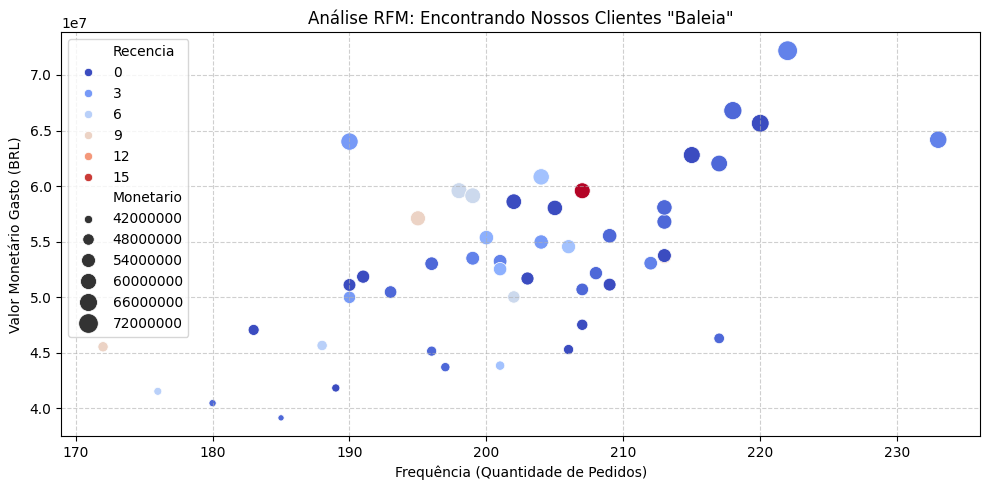

Top 5 Clientes 'Campeões' Absolutos:


,id_client,Recencia,Frequencia,Monetario
41,42,2,222,72187369.50
8,9,1,218,66788855.35
1,2,0,220,65652931.35
14,15,2,233,64171776.55
46,47,3,190,64003343.75


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')
vendas['sale_date_dt'] = pd.to_datetime(vendas['sale_date'], format='mixed', dayfirst=True)

# Data atual para o cálculo da Recência (Assumindo final de 2024 como o "Hoje" da LH)
data_atual = vendas['sale_date_dt'].max()

# Agregando RFM
rfm = vendas.groupby('id_client').agg(
    Recencia=('sale_date_dt', lambda x: (data_atual - x.max()).days),
    Frequencia=('id', 'count'),
    Monetario=('total', 'sum')
).reset_index()

# Visualizando relação entre Frequência e Valor Gasto
plt.figure(figsize=(10, 5))
sns.scatterplot(data=rfm, x='Frequencia', y='Monetario', size='Monetario', sizes=(20, 200), hue='Recencia', palette='coolwarm')
plt.title('Análise RFM: Encontrando Nossos Clientes "Baleia"')
plt.xlabel('Frequência (Quantidade de Pedidos)')
plt.ylabel('Valor Monetário Gasto (BRL)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Mostrar a elite do RFM (Os VIPs)
print("Top 5 Clientes 'Campeões' Absolutos:")
display(rfm.sort_values(by=['Monetario', 'Frequencia'], ascending=[False, False]).head(5))

### 2. O Princípio de Pareto (A Regra 80/20 de Faturamento)
Será que a LH Nautical precisa de centenas de produtos diferentes em estoque? A teoria de Pareto afirma que 80% do faturamento vem de apenas 20% dos produtos do portfólio.
**Insight Prático:** Se confirmarmos o gráfico de funil decaído severamente, a empresa pode cortar os custos logísticos abandonando os 80% de produtos da cauda longa que só servem para oxidar no galpão, focando no reabastecimento cego dos "Heróis"!

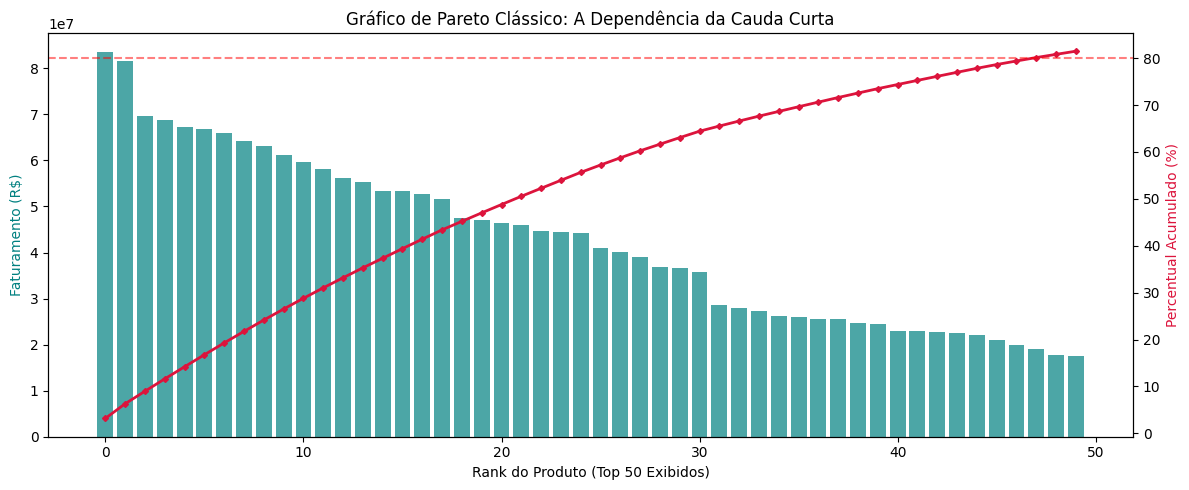

[47 de 150 produtos] são os responsáveis por bater 80% das metas da LH Nautical.
Isso significa que míseros 31.3% do catálogo sustentam a empresa nas costas!


In [14]:
# Faturamento por produto
fat_produtos = vendas.groupby('id_product')['total'].sum().sort_values(ascending=False).reset_index()
fat_produtos['acumulado_pct'] = fat_produtos['total'].cumsum() / fat_produtos['total'].sum() * 100

# Plot Pareto
fig, ax1 = plt.subplots(figsize=(12, 5))

# Eixo 1 (Barras do Faturamento Individual)
# Limitar visualmente os top 50 produtos para o grafico nao virar uma mancha
fat_view = fat_produtos.head(50)

# Eixo 1
ax1.bar(fat_view.index, fat_view['total'], color='teal', alpha=0.7)
ax1.set_ylabel('Faturamento (R$)', color='teal')
ax1.set_xlabel('Rank do Produto (Top 50 Exibidos)')

# Eixo 2 (Linha Acumulada em %)
ax2 = ax1.twinx()
ax2.plot(fat_view.index, fat_view['acumulado_pct'], color='crimson', marker='D', ms=3, linewidth=2)
ax2.axhline(80, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Percentual Acumulado (%)', color='crimson')

plt.title('Gráfico de Pareto Clássico: A Dependência da Cauda Curta')
plt.tight_layout()
plt.show()

# Verificando a tese na totalidade (100% dos dados)
total_prods = len(fat_produtos)
prods_fazendo_80 = len(fat_produtos[fat_produtos['acumulado_pct'] <= 80])

print(f"[{prods_fazendo_80} de {total_prods} produtos] são os responsáveis por bater 80% das metas da LH Nautical.")
print(f"Isso significa que míseros {round((prods_fazendo_80/total_prods)*100, 1)}% do catálogo sustentam a empresa nas costas!")

### 3. A Visão Oposta da Questão 4: Os Campeões de Lucro
Anteriormente abrimos a caixa de "Prejuízo Cambial" sobre vendas cruas na Questão 4. Agora, para balancear o espírito de crescimento, levantamos a Tábua de **Lucro Real Absoluto**.
**Insight Prático:** Quem salvou a pele do Sr. Almir após o desastre dos câmbios desfavoráveis? Aqui mapeamos a rentabilidade limpa (Revenue - USD Custo * Cambio) para proteger os portfólios sadios

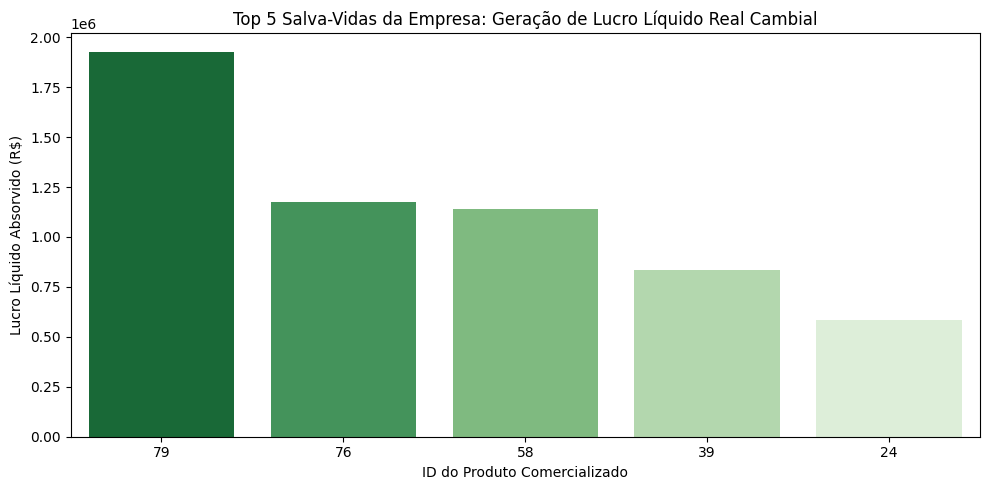

In [15]:
# Reutilizando os dados da etapa final construída no problema 4
custos = pd.read_csv('../data/processed/custos_importacao.csv')
import requests

# Recarga segura
custos['start_date_dt'] = pd.to_datetime(custos['start_date'], format='%d/%m/%Y')
vendas_copy = vendas.copy().sort_values('sale_date_dt')
custos_copy = custos.copy().rename(columns={'product_id': 'id_product'}).sort_values('start_date_dt')

# Match AsOf
df_m = pd.merge_asof(vendas_copy, custos_copy[['id_product', 'start_date_dt', 'usd_price']], left_on='sale_date_dt', right_on='start_date_dt', by='id_product', direction='backward')

# Resgatando PTAX do BCB de forma compacta e ágil
url_bcb = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'&$format=json"
resp = requests.get(url_bcb).json()
df_pt = pd.DataFrame(resp['value'])
df_pt['data_ptax'] = pd.to_datetime(df_pt['dataHoraCotacao']).dt.normalize()
df_pt = df_pt[['data_ptax', 'cotacaoVenda']].drop_duplicates('data_ptax').sort_values('data_ptax')

df_fin = pd.merge_asof(df_m, df_pt, left_on='sale_date_dt', right_on='data_ptax', direction='backward')

# O Pulo do Gato (Lucro Margem Real = Faturamento Bruto - Custos de Câmbio de Material do Exterior)
df_fin['custo_total_brl'] = df_fin['qtd'] * df_fin['usd_price'] * df_fin['cotacaoVenda']
df_fin['lucro_liquido'] = df_fin['total'] - df_fin['custo_total_brl']

# Ranqueando os Heróis e transformando ID do produto em String para Eixo XY Discreto e Imunidade ao Warning
lucrativos = df_fin.groupby('id_product')['lucro_liquido'].sum().sort_values(ascending=False).head(5).reset_index()
lucrativos['id_str'] = lucrativos['id_product'].astype(str)

plt.figure(figsize=(10, 5))
import seaborn as sns
sns.barplot(data=lucrativos, x='id_str', y='lucro_liquido', hue='id_str', palette='Greens_r', legend=False)
plt.title('Top 5 Salva-Vidas da Empresa: Geração de Lucro Líquido Real Cambial')
plt.xlabel('ID do Produto Comercializado')
plt.ylabel('Lucro Líquido Absorvido (R$)')
plt.tight_layout()
plt.show()

### 4. Sazonalidade Temporal: O Assombro do Verão
O último apontamento do Sr. Almir era sobre faltar itens no verão, enquanto no Inverno sobravam. A Inteligência de ML de média dos últimos 7 dias recomendada na Questão 7 falha em prever o Verão até que o desastre atinja o cofre da Marina (pois não percebe tendências a longo prazo, apenas o que passou no retrovisor imediato).
**Insight Prático:** Demonstrar por mês/ano qual é de fato o "calor sazonal" da Marina, provando à diretoria que eles deveriam antecipar e entupir o estoque preventivamente na Janela dos Meses Altos.

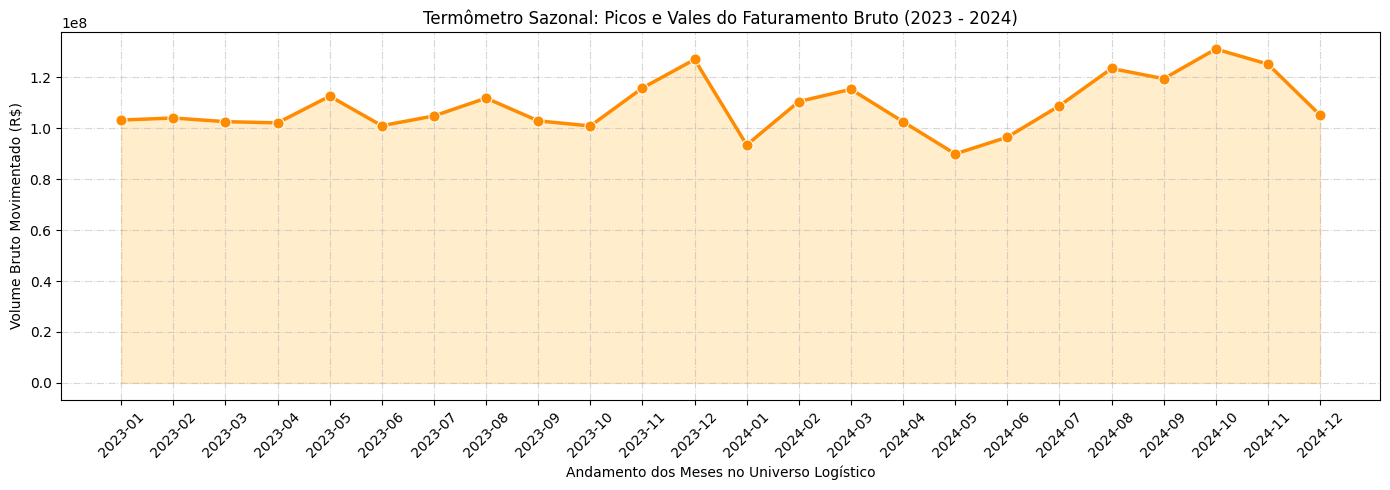

 Insight Conclusivo: A volatilidade clara dos picos e rebaixos prova 
 visualmente a necessidade de migrar a base logística da Marina 
 para Previsões Avançadas (S-ARIMA/Prophet) ao invés do Feeling ou da Média Simples Enganosa.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar agrupamento Mensal (Year-Month) para observar curvas cíclicas de negócio
vendas['ano_mes'] = vendas['sale_date_dt'].dt.to_period('M')

sazonalidade = vendas.groupby('ano_mes')['total'].sum().reset_index()
sazonalidade['ano_mes_str'] = sazonalidade['ano_mes'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=sazonalidade, x='ano_mes_str', y='total', marker='o', color='darkorange', linewidth=2.5, markersize=8)
plt.fill_between(sazonalidade['ano_mes_str'], sazonalidade['total'], alpha=0.2, color='orange')
plt.title('Termômetro Sazonal: Picos e Vales do Faturamento Bruto (2023 - 2024)')
plt.xlabel('Andamento dos Meses no Universo Logístico')
plt.ylabel('Volume Bruto Movimentado (R$)')
plt.xticks(rotation=45)
plt.grid(True, linestyle= '-.', alpha=0.5)
plt.tight_layout()
plt.show()

print(" Insight Conclusivo: A volatilidade clara dos picos e rebaixos prova \n visualmente a necessidade de migrar a base logística da Marina \n para Previsões Avançadas (S-ARIMA/Prophet) ao invés do Feeling ou da Média Simples Enganosa.")